In [1]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder\
       .master("local[*]")\
       .appName("Spark_App")\
       .getOrCreate()

In [2]:
spark.sparkContext

<SparkContext master=local[*] appName=Spark_App>

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pyspark.sql.functions as f
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

In [5]:
data = [['tom', 10], ['nick', 15], ['juli', 14]] 
pd_df = pd.DataFrame(data, columns = ['Name', 'Age'])
df_spark = spark.createDataFrame(pd_df)

In [6]:
df_spark.show(truncate = False)

+----+---+
|Name|Age|
+----+---+
|tom |10 |
|nick|15 |
|juli|14 |
+----+---+



In [7]:
df_spark.toPandas().head()

,Name,Age
0,tom,10
1,nick,15
2,juli,14


In [8]:
df = spark.read.csv('Vermont_Vendor_Payments.csv', header='true', inferSchema = True)

In [9]:
df = (df
      .withColumn("Amount", f.col("Amount").cast(DoubleType()))
      .withColumn("Quarter Ending", f.to_date(f.col("Quarter Ending"),"MM/dd/yyy"))
      .withColumn("Fund", f.col("Amount").cast(IntegerType()))
     )

In [10]:
df.printSchema()

root
 |-- Quarter Ending: date (nullable = true)
 |-- Department: string (nullable = true)
 |-- UnitNo: integer (nullable = true)
 |-- Vendor Number: string (nullable = true)
 |-- Vendor: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- DeptID Description: string (nullable = true)
 |-- DeptID: string (nullable = true)
 |-- Amount: double (nullable = true)
 |-- Account: string (nullable = true)
 |-- AcctNo: string (nullable = true)
 |-- Fund Description: string (nullable = true)
 |-- Fund: integer (nullable = true)



In [11]:
#we can use the columns attribute just like with pandas
for x in df.columns:
    print(x)

Quarter Ending
Department
UnitNo
Vendor Number
Vendor
City
State
DeptID Description
DeptID
Amount
Account
AcctNo
Fund Description
Fund


In [12]:
print(f"Rows: {df.count()}, Columns: {len(df.columns)}")

Rows: 1680170, Columns: 14


In [13]:
# collect() is an action operation that is used to retrieve all the elements of the dataset (from all nodes) to the driver node. 
# We should use the collect() on smaller dataset usually after filter(), group() e.t.c.
# Retrieving larger datasets results in OutOfMemory error.
dataCollect = df.limit(5).collect()
print(dataCollect)

[Row(Quarter Ending=datetime.date(2009, 9, 30), Department='Environmental Conservation', UnitNo=6140, Vendor Number='0000276016', Vendor='1st Run Computer Services Inc', City=None, State='NY', DeptID Description='WQD - Waterbury', DeptID='6140040206', Amount=930.0, Account='Rep&Maint-Info Tech Hardware', AcctNo='513000', Fund Description='Environmental Permit Fund', Fund=930), Row(Quarter Ending=datetime.date(2009, 9, 30), Department='Environmental Conservation', UnitNo=6140, Vendor Number='0000276016', Vendor='1st Run Computer Services Inc', City=None, State='NY', DeptID Description='Water Supply Division - Wtby', DeptID='6140040406', Amount=930.0, Account='Rep&Maint-Info Tech Hardware', AcctNo='513000', Fund Description='Environmental Permit Fund', Fund=930), Row(Quarter Ending=datetime.date(2009, 9, 30), Department="Vermont Veterans' Home", UnitNo=3300, Vendor Number='0000284121', Vendor='210 Innovations LLC', City=None, State='CT', DeptID Description='MAINTENANCE', DeptID='33000103

In [14]:
df.limit(10).toPandas().head()

,Quarter Ending,Department,UnitNo,Vendor Number,Vendor,City,State,DeptID Description,DeptID,Amount,Account,AcctNo,Fund Description,Fund
0,2009-09-30,Environmental Conservation,6140,0000276016,1st Run Computer Services Inc,None,NY,WQD - Waterbury,6140040206,930.0,Rep&Maint-Info Tech Hardware,513000,Environmental Permit Fund,930
1,2009-09-30,Environmental Conservation,6140,0000276016,1st Run Computer Services Inc,None,NY,Water Supply Division - Wtby,6140040406,930.0,Rep&Maint-Info Tech Hardware,513000,Environmental Permit Fund,930
2,2009-09-30,Vermont Veterans' Home,3300,0000284121,210 Innovations LLC,None,CT,MAINTENANCE,3300010300,24.0,Freight & Express Mail,517300,Vermont Medicaid,24
3,2009-09-30,Vermont Veterans' Home,3300,0000284121,210 Innovations LLC,None,CT,MAINTENANCE,3300010300,420.0,Building Maintenance Supplies,520200,Vermont Medicaid,420
4,2009-09-30,Corrections,3480,0000207719,21st Century Cellular,None,PA,Brattleboro P&P,3480004630,270.8,Telecom-Wireless Phone Service,516659,General Fund,270


In [15]:
df.describe('Amount').toPandas().head(20)

,summary,Amount
0,count,1679823
1,mean,185564.902983654
2,stddev,1.4200185374028489E7
3,min,-2880183.34
4,max,6.10001E9


In [16]:
n_classes = 10
prob = list(np.arange(1, n_classes, 1)/n_classes * 100)
prob = [str(int(p)) + "%" for p in prob]
df.select('Amount').summary("min", *prob, "max").toPandas().head(20)

,summary,Amount
0,min,-2880183.34
1,10%,18.0
2,20%,46.88
3,30%,100.0
4,40%,194.0
5,50%,371.6
6,60%,711.0
7,70%,1486.57
8,80%,3713.58
9,90%,14656.33


In [17]:
df\
.select("Fund Description")\
.dropDuplicates()\
.limit(20)\
.show(truncate = False)

+------------------------------+
|Fund Description              |
+------------------------------+
|HE-Third Party Reimbursement  |
|Snowmobile Trails             |
|HE-Asbestos Fees              |
|Workforce Ed & Training Fund  |
|DAD-Vending Facilities        |
|AF&M-Agricultural Fees        |
|F&W Federal Revenues Fund     |
|Electric Power Sales Fund     |
|VDPC State Portion            |
|Worker's Comp Admin Fund      |
|Water/Sewer                   |
|FPR - Land Acquisitions       |
|Single Audit Revolving Fund   |
|Protection Projects Fund      |
|Attorney Admission,Licensing,&|
|Transportation FAA Fund       |
|New York Medicaid             |
|Federal Surplus Property Fund |
|Entergy-Windham Cnty Econ Dev |
|Life Insurance Fund           |
+------------------------------+



In [18]:
df\
.select("Quarter Ending", "Department", "Amount", "State")\
.orderBy(f.col("Quarter Ending").desc())\
.show(truncate = False)

+--------------+------------------------------+---------+-----+
|Quarter Ending|Department                    |Amount   |State|
+--------------+------------------------------+---------+-----+
|2020-03-31    |Children and Families         |1067.39  |GA   |
|2020-03-31    |Disabilities Aging Ind. Living|430.93   |IL   |
|2020-03-31    |Buildings & Gen Serv-Prop     |115779.12|VT   |
|2020-03-31    |Buildings & Gen Serv-Prop     |4117.5   |VT   |
|2020-03-31    |Buildings & Gen Serv-Prop     |1800.0   |VT   |
|2020-03-31    |Department of Liquor & Lottery|31.65    |VT   |
|2020-03-31    |Department of Liquor & Lottery|20435.93 |VT   |
|2020-03-31    |Criminal Justice Trng Council |2307.5   |IL   |
|2020-03-31    |Buildings & Gen Serv-Prop     |283375.05|VT   |
|2020-03-31    |Buildings & Gen Serv-Prop     |33471.93 |VT   |
|2020-03-31    |Department of Liquor & Lottery|3981.59  |VT   |
|2020-03-31    |Natural Resources Board       |246.4    |VT   |
|2020-03-31    |Offender Work Program   

In [19]:
dept_list = ["Transportation Agency", 
             "Children and Families",
             "Buildings & Gen Serv-Prop",
             "Children and Family Services",
             "Health"
            ]

df\
.filter(f.col("Department").isin(dept_list))\
.select("Quarter Ending", "Department", "Amount", "State")\
.orderBy(f.col("Quarter Ending").desc())\
.show(truncate = False)

+--------------+-------------------------+---------+-----+
|Quarter Ending|Department               |Amount   |State|
+--------------+-------------------------+---------+-----+
|2020-03-31    |Children and Families    |1067.39  |GA   |
|2020-03-31    |Buildings & Gen Serv-Prop|482.77   |GA   |
|2020-03-31    |Buildings & Gen Serv-Prop|115779.12|VT   |
|2020-03-31    |Buildings & Gen Serv-Prop|4117.5   |VT   |
|2020-03-31    |Buildings & Gen Serv-Prop|1800.0   |VT   |
|2020-03-31    |Buildings & Gen Serv-Prop|283375.05|VT   |
|2020-03-31    |Buildings & Gen Serv-Prop|33471.93 |VT   |
|2020-03-31    |Buildings & Gen Serv-Prop|4590.0   |VT   |
|2020-03-31    |Buildings & Gen Serv-Prop|31207.32 |VT   |
|2020-03-31    |Transportation Agency    |146.76   |NC   |
|2020-03-31    |Transportation Agency    |205.74   |NC   |
|2020-03-31    |Transportation Agency    |109.0    |VT   |
|2020-03-31    |Transportation Agency    |8745.0   |VT   |
|2020-03-31    |Transportation Agency    |280.0    |VT  

In [20]:
dept_list = ["Transportation Agency", 
             "Children and Families",
             "Buildings & Gen Serv-Prop",
             "Children and Family Services",
             "Health"
            ]

df\
.filter(~f.col("Department").isin(dept_list))\
.select("Quarter Ending", "Department", "Amount", "State")\
.orderBy(f.col("Quarter Ending").desc())\
.show(truncate = False)

+--------------+------------------------------+--------+-----+
|Quarter Ending|Department                    |Amount  |State|
+--------------+------------------------------+--------+-----+
|2020-03-31    |Department of Liquor & Lottery|31.65   |VT   |
|2020-03-31    |Public Safety                 |36.0    |VT   |
|2020-03-31    |Department of Liquor & Lottery|20435.93|VT   |
|2020-03-31    |Criminal Justice Trng Council |2307.5  |IL   |
|2020-03-31    |Department of Liquor & Lottery|3981.59 |VT   |
|2020-03-31    |Natural Resources Board       |246.4   |VT   |
|2020-03-31    |Offender Work Program         |4029.68 |PA   |
|2020-03-31    |Offender Work Program         |41688.0 |PA   |
|2020-03-31    |Transportation Agency-Prop    |1097.33 |PA   |
|2020-03-31    |Housing & Comm Development    |80.0    |VT   |
|2020-03-31    |Corrections                   |400.0   |IL   |
|2020-03-31    |Military                      |11183.43|VT   |
|2020-03-31    |Judiciary                     |250.0   

In [21]:
df\
.filter(f.col('Amount') >= 0)\
.filter(f.col('Department')=='Education')\
.select('Quarter Ending', 'Department', 'Amount', 'State')\
.show(truncate = False)

+--------------+----------+---------+-----+
|Quarter Ending|Department|Amount   |State|
+--------------+----------+---------+-----+
|2009-09-30    |Education |9423.36  |VT   |
|2009-09-30    |Education |110.03   |IL   |
|2009-09-30    |Education |332.58   |IL   |
|2009-09-30    |Education |60.08    |IL   |
|2009-09-30    |Education |284.83   |IL   |
|2009-09-30    |Education |377.15   |IL   |
|2009-09-30    |Education |114.74   |IL   |
|2009-09-30    |Education |129.72   |IL   |
|2009-09-30    |Education |114.54   |IL   |
|2009-09-30    |Education |375.6    |IL   |
|2009-09-30    |Education |192.64   |IL   |
|2009-09-30    |Education |317.68   |IL   |
|2009-12-31    |Education |105.48   |VT   |
|2009-09-30    |Education |1570.35  |IL   |
|2009-09-30    |Education |46107.75 |VT   |
|2009-09-30    |Education |4500.0   |VT   |
|2009-09-30    |Education |122659.28|VT   |
|2009-09-30    |Education |1529.99  |VT   |
|2009-09-30    |Education |101730.57|VT   |
|2009-09-30    |Education |2322.

In [22]:
n = df\
.select("Department")\
.distinct()\
.count()

print(f"N = {n}")

N = 111


In [23]:
df\
.groupBy("Department")\
.count()\
.orderBy(f.col("count").desc())\
.show(truncate = False)

+------------------------------+------+
|Department                    |count |
+------------------------------+------+
|Transportation Agency         |163552|
|Children and Families         |130847|
|Agency of Transportation      |102395|
|Buildings & Gen Serv-Prop     |98528 |
|Children and Family Services  |94097 |
|Corrections                   |76231 |
|Health                        |73193 |
|Judiciary                     |63311 |
|Public Safety                 |58697 |
|Education Agency              |47785 |
|Fish & Wildlife               |47504 |
|Education                     |44489 |
|Environmental Conservation    |32947 |
|Tax                           |31695 |
|Disabilities Aging Ind. Living|26214 |
|Forests, Parks & Recreation   |25859 |
|Defender General's Office     |23200 |
|Buildings & Gen Serv-Gov'tal  |21263 |
|Aging and Independent Living  |19831 |
|Agriculture, Food&Mrkts Agency|19623 |
+------------------------------+------+
only showing top 20 rows



In [24]:
df\
.groupBy("Department")\
.agg(f.count(f.lit(1)).alias("count"))\
.orderBy(f.col("count").desc())\
.show(truncate = False)

+------------------------------+------+
|Department                    |count |
+------------------------------+------+
|Transportation Agency         |163552|
|Children and Families         |130847|
|Agency of Transportation      |102395|
|Buildings & Gen Serv-Prop     |98528 |
|Children and Family Services  |94097 |
|Corrections                   |76231 |
|Health                        |73193 |
|Judiciary                     |63311 |
|Public Safety                 |58697 |
|Education Agency              |47785 |
|Fish & Wildlife               |47504 |
|Education                     |44489 |
|Environmental Conservation    |32947 |
|Tax                           |31695 |
|Disabilities Aging Ind. Living|26214 |
|Forests, Parks & Recreation   |25859 |
|Defender General's Office     |23200 |
|Buildings & Gen Serv-Gov'tal  |21263 |
|Aging and Independent Living  |19831 |
|Agriculture, Food&Mrkts Agency|19623 |
+------------------------------+------+
only showing top 20 rows



In [25]:
df\
.groupBy("State")\
.count()\
.sort("count", ascending=False)\
.show(truncate = False)

+-----+-------+
|State|count  |
+-----+-------+
|VT   |1286349|
|MA   |70924  |
|NY   |41691  |
|IL   |41519  |
|PA   |35053  |
|NH   |31211  |
|GA   |23337  |
|ME   |16887  |
|CT   |16425  |
|CA   |13760  |
|NJ   |11551  |
|TX   |11179  |
|MO   |11098  |
|FL   |6412   |
|MD   |5627   |
|OH   |5184   |
|KY   |5104   |
|NC   |4321   |
|VA   |4280   |
|MN   |4257   |
+-----+-------+
only showing top 20 rows



In [26]:
df\
.groupBy('Department')\
.sum('Amount')\
.withColumnRenamed('sum(Amount)','Sum of Amount')\
.show(truncate = False)

+----------------------------+--------------------+
|Department                  |Sum of Amount       |
+----------------------------+--------------------+
|Labor                       |7.700329007000002E7 |
|Vermont Health Access       |7.652163011169997E9 |
|Public Service Board        |4055801.6000000006  |
|Natural Resources Agency    |3.2574205670000013E7|
|Children and Family Services|1.2813687506999989E9|
|Aging and Independent Living|7.893938401199995E8 |
|Education                   |3.166972698639998E9 |
|Administration Agency       |6.668231414800003E8 |
|Children and Families       |1.9263854047699993E9|
|DLL - Div of Liquor Control |1.5744910309999997E7|
|Finance & Management-FMS    |6086495.499999999   |
|State Treasurer-Fiduciary   |2.5927613519999993E8|
|Office of VT Health Access  |1.4660943494399996E9|
|Human Rights Commission     |875838.4700000001   |
|Transportation Agency       |2.891035008009994E9 |
|Secretary of State          |1.2994913350000001E7|
|Housing & C

In [27]:
df\
.filter(df.Department == 'Education')\
.groupBy('Department')\
.sum('Amount')\
.withColumnRenamed('sum(Amount)','Sum of Amount')\
.show(truncate = False)

+----------+-------------------+
|Department|Sum of Amount      |
+----------+-------------------+
|Education |3.166972698639998E9|
+----------+-------------------+



In [28]:
df\
.filter(df.Department != 'Education')\
.groupBy('Department')\
.sum('Amount')\
.withColumnRenamed('sum(Amount)','Sum of Amount')\
.show(truncate = False)

+----------------------------+--------------------+
|Department                  |Sum of Amount       |
+----------------------------+--------------------+
|Labor                       |7.700329007000002E7 |
|Vermont Health Access       |7.652163011169997E9 |
|Public Service Board        |4055801.6000000006  |
|Natural Resources Agency    |3.2574205670000013E7|
|Children and Family Services|1.2813687506999989E9|
|Aging and Independent Living|7.893938401199995E8 |
|Administration Agency       |6.668231414800003E8 |
|Children and Families       |1.9263854047699993E9|
|DLL - Div of Liquor Control |1.5744910309999997E7|
|Finance & Management-FMS    |6086495.499999999   |
|State Treasurer-Fiduciary   |2.5927613519999993E8|
|Office of VT Health Access  |1.4660943494399996E9|
|Human Rights Commission     |875838.4700000001   |
|Transportation Agency       |2.891035008009994E9 |
|Secretary of State          |1.2994913350000001E7|
|Housing & Comm Affairs      |8.149393504000004E7 |
|AOT Proprie

In [29]:
df\
.groupBy('Department')\
.sum('Amount')\
.withColumnRenamed('sum(Amount)','Sum of Amount')\
.withColumn('Amount in millions', f.col('Sum of Amount')/1000000)\
.show(10, truncate = False)

+----------------------------+--------------------+------------------+
|Department                  |Sum of Amount       |Amount in millions|
+----------------------------+--------------------+------------------+
|Labor                       |7.700329007000002E7 |77.00329007000002 |
|Vermont Health Access       |7.652163011169997E9 |7652.163011169997 |
|Public Service Board        |4055801.6000000006  |4.055801600000001 |
|Natural Resources Agency    |3.2574205670000013E7|32.57420567000001 |
|Children and Family Services|1.2813687506999989E9|1281.3687506999988|
|Aging and Independent Living|7.893938401199995E8 |789.3938401199995 |
|Education                   |3.166972698639998E9 |3166.972698639998 |
|Administration Agency       |6.668231414800003E8 |666.8231414800002 |
|Children and Families       |1.9263854047699993E9|1926.3854047699992|
|DLL - Div of Liquor Control |1.5744910309999997E7|15.744910309999996|
+----------------------------+--------------------+------------------+
only s

In [30]:
df\
.where(f.col("Quarter Ending").isNotNull() & f.col("Department").isNotNull())\
.withColumn("Quarter Ending Year", f.year("Quarter Ending"))\
.where(f.col("Quarter Ending Year").between(2010, 2013))\
.groupBy("Department")\
.pivot("Quarter Ending Year")\
.agg(f.sum("amount"))\
.orderBy("Department")\
.show(truncate = False)

+------------------------------+--------------------+---------------------+--------------------+---------------------+
|Department                    |2010                |2011                 |2012                |2013                 |
+------------------------------+--------------------+---------------------+--------------------+---------------------+
|AOT Proprietary Funds         |1.0788598300000003E7|1.6855099150000013E7 |1.2337161650000002E7|1.2303850850000001E7 |
|Administration Agency         |NULL                |NULL                 |NULL                |4072449.7000000007   |
|Agency of Admin Sec Office    |1.005093884E7       |231392.70999999993   |1.2960755820000002E7|5415556.06           |
|Agency of Transportation      |4.272671200899995E8 |4.8423180798999894E8 |5.1344663991999996E8|2.931514106899992E8  |
|Aging & Ind Living-Proprietary|13716.25            |NULL                 |NULL                |NULL                 |
|Aging and Independent Living  |1.74454533170000

In [31]:
df\
.withColumn("Quarter Ending DT", f.col("Quarter Ending").cast("timestamp"))\
.groupBy()\
.agg(f.min("Quarter Ending DT").alias("Min. Quarter Ending DT"), 
     f.max("Quarter Ending DT").alias("Max. Quarter Ending DT"))\
.show(truncate = False)

+----------------------+----------------------+
|Min. Quarter Ending DT|Max. Quarter Ending DT|
+----------------------+----------------------+
|2009-09-30 00:00:00   |2020-03-31 00:00:00   |
+----------------------+----------------------+



In [32]:
df\
.filter(f.col("Quarter Ending").between("2015-01-01","2020-01-01"))\
.select("Quarter Ending", "Department", "Amount", "State")\
.orderBy(f.col("Quarter Ending").desc())\
.show(truncate = False)

+--------------+---------------------+----------+-----+
|Quarter Ending|Department           |Amount    |State|
+--------------+---------------------+----------+-----+
|2019-12-31    |Administration Agency|1299967.25|PA   |
|2019-12-31    |Libraries            |100.0     |VT   |
|2019-12-31    |Administration Agency|88128.0   |PA   |
|2019-12-31    |Libraries            |100.0     |VT   |
|2019-12-31    |Administration Agency|1194327.45|PA   |
|2019-12-31    |Libraries            |50.0      |VT   |
|2019-12-31    |Administration Agency|242704.95 |PA   |
|2019-12-31    |Libraries            |100.0     |VT   |
|2019-12-31    |Administration Agency|71904.79  |PA   |
|2019-12-31    |Administration Agency|50.0      |VT   |
|2019-12-31    |Administration Agency|50.0      |VT   |
|2019-12-31    |Administration Agency|50.0      |VT   |
|2019-12-31    |Administration Agency|100.0     |VT   |
|2019-12-31    |Administration Agency|100.0     |VT   |
|2019-12-31    |Administration Agency|100.0     

In [33]:
df\
.filter(f.col("Quarter Ending").between(pd.to_datetime("2015-01-01"), pd.to_datetime("2020-01-01")))\
.select("Quarter Ending", "Department", "Amount", "State")\
.orderBy(f.col("Quarter Ending").desc())\
.show(truncate = False)

+--------------+---------------------+----------+-----+
|Quarter Ending|Department           |Amount    |State|
+--------------+---------------------+----------+-----+
|2019-12-31    |Administration Agency|1299967.25|PA   |
|2019-12-31    |Libraries            |100.0     |VT   |
|2019-12-31    |Administration Agency|88128.0   |PA   |
|2019-12-31    |Libraries            |100.0     |VT   |
|2019-12-31    |Administration Agency|1194327.45|PA   |
|2019-12-31    |Libraries            |50.0      |VT   |
|2019-12-31    |Administration Agency|242704.95 |PA   |
|2019-12-31    |Libraries            |100.0     |VT   |
|2019-12-31    |Administration Agency|71904.79  |PA   |
|2019-12-31    |Administration Agency|50.0      |VT   |
|2019-12-31    |Administration Agency|50.0      |VT   |
|2019-12-31    |Administration Agency|50.0      |VT   |
|2019-12-31    |Administration Agency|100.0     |VT   |
|2019-12-31    |Administration Agency|100.0     |VT   |
|2019-12-31    |Administration Agency|100.0     

In [34]:
df\
.select("AcctNo", "Account")\
.withColumn("Account_Desc", f.concat_ws("-", f.col("AcctNo"), f.col("Account")))\
.withColumn("AccName", f.trim(f.regexp_replace("Account_Desc", "[^a-z A-Z]", "")))\
.show(truncate = False)

+------+------------------------------+-------------------------------------+-----------------------------+
|AcctNo|Account                       |Account_Desc                         |AccName                      |
+------+------------------------------+-------------------------------------+-----------------------------+
|513000|Rep&Maint-Info Tech Hardware  |513000-Rep&Maint-Info Tech Hardware  |RepMaintInfo Tech Hardware   |
|513000|Rep&Maint-Info Tech Hardware  |513000-Rep&Maint-Info Tech Hardware  |RepMaintInfo Tech Hardware   |
|517300|Freight & Express Mail        |517300-Freight & Express Mail        |Freight  Express Mail        |
|520200|Building Maintenance Supplies |520200-Building Maintenance Supplies |Building Maintenance Supplies|
|516659|Telecom-Wireless Phone Service|516659-Telecom-Wireless Phone Service|TelecomWireless Phone Service|
|516659|Telecom-Wireless Phone Service|516659-Telecom-Wireless Phone Service|TelecomWireless Phone Service|
|520500|Other General Suppli

In [35]:
df\
.select("Fund Description", "Amount")\
.where(f.col("Fund Description").isNotNull())\
.sort("Amount", ascending=False)\
.withColumnRenamed("Amount", "Cost")\
.show(truncate = False)

+----------------+-------------+
|Fund Description|Cost         |
+----------------+-------------+
|550000          |6.10001E9    |
|520210          |1.160550371E9|
|520211          |1.160550371E9|
|519000          |1.160550371E9|
|521320          |1.160550371E9|
|520200          |1.160550371E9|
|519000          |1.160550371E9|
|521320          |1.160550371E9|
|520215          |1.160550371E9|
|521320          |1.160550371E9|
|521320          |1.160550371E9|
|520200          |1.160550371E9|
|521320          |1.160550371E9|
|520200          |1.160550371E9|
|514500          |1.160550371E9|
|520230          |1.160550371E9|
|520210          |1.160550371E9|
|521320          |1.160550371E9|
|520211          |1.160550371E9|
|520500          |1.160550371E9|
+----------------+-------------+
only showing top 20 rows



In [36]:
value = df.select("Fund Description").first()[0]
print(value)

Environmental Permit Fund


In [37]:
cols = df.select("Fund Description").distinct().limit(10).rdd.flatMap(lambda x: x).collect()

for x in cols:
    print(x)

HE-Third Party Reimbursement
Snowmobile Trails
HE-Asbestos Fees
Workforce Ed & Training Fund
DAD-Vending Facilities
AF&M-Agricultural Fees
F&W Federal Revenues Fund
Electric Power Sales Fund
VDPC State Portion
Worker's Comp Admin Fund


In [38]:
df_agg = df\
.groupBy("Department")\
.count()\
.orderBy(f.col("count").desc())\
.limit(10)

dept_list = df_agg.select("Department").rdd.flatMap(lambda x: x).collect()

for x in dept_list:
    print(x)

Transportation Agency
Children and Families
Agency of Transportation
Buildings & Gen Serv-Prop
Children and Family Services
Corrections
Health
Judiciary
Public Safety
Education Agency


In [39]:
state_df = (df
.select("State")
.where(f.col("State").isNotNull())
.where("State like 'N%'")
.where(f.length("State")<=3)
.drop_duplicates()
.sort("State"))

state_df.show(truncate = False)

+-----+
|State|
+-----+
|NB   |
|NC   |
|ND   |
|NE   |
|NF   |
|NH   |
|NJ   |
|NL   |
|NM   |
|NS   |
|NSW  |
|NV   |
|NY   |
+-----+



In [40]:
state_df = state_df.cache()

In [41]:
def func(col1, col2):
    if col1 == 'NSW' or col2 == 'NY':
        return 1
    return None

func_udf = f.udf(func, IntegerType())

state_df = (state_df
            .withColumn("expr_if", f.expr("IF(State=='NH' OR State=='NL', 1, NULL)"))
            .withColumn("when_col", f.when((f.col("State") =='NC') | (f.col("State") =='NE'), 1).otherwise(None))
            .withColumn("func_udf", func_udf(f.col("State"), f.col("State")))
            .withColumn('coalesce', f.coalesce(f.col("expr_if"), f.col("when_col"), f.col("func_udf"), f.lit(0))))

state_df.show(truncate = False)

+-----+-------+--------+--------+--------+
|State|expr_if|when_col|func_udf|coalesce|
+-----+-------+--------+--------+--------+
|NB   |NULL   |NULL    |NULL    |0       |
|NC   |NULL   |1       |NULL    |1       |
|ND   |NULL   |NULL    |NULL    |0       |
|NE   |NULL   |1       |NULL    |1       |
|NF   |NULL   |NULL    |NULL    |0       |
|NH   |1      |NULL    |NULL    |1       |
|NJ   |NULL   |NULL    |NULL    |0       |
|NL   |1      |NULL    |NULL    |1       |
|NM   |NULL   |NULL    |NULL    |0       |
|NS   |NULL   |NULL    |NULL    |0       |
|NSW  |NULL   |NULL    |1       |1       |
|NV   |NULL   |NULL    |NULL    |0       |
|NY   |NULL   |NULL    |1       |1       |
+-----+-------+--------+--------+--------+



In [42]:
state_df.unpersist()

DataFrame[State: string, expr_if: int, when_col: int, func_udf: int, coalesce: int]

In [43]:
window = Window.partitionBy("Department").orderBy(f.col("Amount").desc())

df_first = (df
    .filter(f.col("Department").isNotNull())
    .withColumn("row_number", f.row_number().over(window))
    .filter("row_number = 1")
    .drop("row_number")
)

df_first.select("Department", "Amount").show(truncate = False)

+------------------------------+-------------+
|Department                    |Amount       |
+------------------------------+-------------+
|AOT Proprietary Funds         |2835575.76   |
|Administration Agency         |3.154938928E7|
|Agency of Admin Sec Office    |1.25E7       |
|Agency of Digital Services    |3958336.27   |
|Agency of Transportation      |2.497654373E7|
|Aging & Ind Living-Proprietary|10000.0      |
|Aging and Independent Living  |3.982599825E7|
|Agriculture, Food & Markets   |860185.0     |
|Agriculture, Food&Mrkts Agency|742827.49    |
|Attorney General's Office     |195152.17    |
|Auditor of Accounts' Office   |759165.0     |
|Auditor of Accounts-Gov'tal   |427652.0     |
|Auditor of Accounts-Prop      |788097.0     |
|Banking Ins Sec Hlth Care Adm |382813.63    |
|Buildings & Gen Serv-Capital  |1.4332717E7  |
|Buildings & Gen Serv-Gov'tal  |400000.0     |
|Buildings & Gen Serv-Prop     |1.160550371E9|
|Center of Crime Victims' Serv |774829.09    |
|Children and

In [44]:
df\
.groupBy("State")\
.count()\
.sort("count", ascending=False)\
.withColumn("State", f.when(f.col("State") == "VT","VT")
                    .when(f.col("State") == "MA","MA")
                    .otherwise("Unknown"))\
.show(10, truncate=False)

+-------+-------+
|State  |count  |
+-------+-------+
|VT     |1286349|
|MA     |70924  |
|Unknown|41691  |
|Unknown|41519  |
|Unknown|35053  |
|Unknown|31211  |
|Unknown|23337  |
|Unknown|16887  |
|Unknown|16425  |
|Unknown|13760  |
+-------+-------+
only showing top 10 rows



In [45]:
df\
.groupBy("State")\
.count()\
.sort("count", ascending=False)\
.withColumn("State", f.expr("case when State = 'VT' then 'VT' " + 
                           "when State = 'MA' then 'MA' " +
                           "else 'Unknown' end"))\
.show(10, truncate=False)

+-------+-------+
|State  |count  |
+-------+-------+
|VT     |1286349|
|MA     |70924  |
|Unknown|41691  |
|Unknown|41519  |
|Unknown|35053  |
|Unknown|31211  |
|Unknown|23337  |
|Unknown|16887  |
|Unknown|16425  |
|Unknown|13760  |
+-------+-------+
only showing top 10 rows



In [46]:
df\
.groupBy("State")\
.count()\
.sort("count", ascending=False)\
.selectExpr("*", "case when State = 'VT' then 'VT' " +
                    "when State = 'MA' then 'MA' " +
                    "else 'Unknown' end as State2")\
.select(f.col("State2").alias("State"), "count")\
.show(10, truncate=False)

+-------+-------+
|State  |count  |
+-------+-------+
|VT     |1286349|
|MA     |70924  |
|Unknown|41691  |
|Unknown|41519  |
|Unknown|35053  |
|Unknown|31211  |
|Unknown|23337  |
|Unknown|16887  |
|Unknown|16425  |
|Unknown|13760  |
+-------+-------+
only showing top 10 rows



In [47]:
df\
.select("Amount")\
.dropDuplicates()\
.fillna({'Amount': 0})\
.show(10)

+-------+
| Amount|
+-------+
|6861.67|
| 679.78|
|   26.7|
|  375.6|
|1207.98|
|1390.35|
| 1501.5|
|  194.7|
| 295.39|
|  305.0|
+-------+
only showing top 10 rows



In [48]:
# I will start by creating a temporary table
df.createOrReplaceTempView('VermontVendor')
# spark.catalog.dropTempView('VermontVendor')

# run query with SQL
sql = """
SELECT `Quarter Ending`, Department, Amount, State FROM VermontVendor
LIMIT 10
"""

spark.sql(sql).show(truncate = False)

+--------------+---------------------------+------+-----+
|Quarter Ending|Department                 |Amount|State|
+--------------+---------------------------+------+-----+
|2009-09-30    |Environmental Conservation |930.0 |NY   |
|2009-09-30    |Environmental Conservation |930.0 |NY   |
|2009-09-30    |Vermont Veterans' Home     |24.0  |CT   |
|2009-09-30    |Vermont Veterans' Home     |420.0 |CT   |
|2009-09-30    |Corrections                |270.8 |PA   |
|2009-09-30    |Corrections                |35.0  |PA   |
|2009-09-30    |Public Safety              |971.4 |PA   |
|2009-09-30    |Agriculture, Food & Markets|60.59 |TX   |
|2009-09-30    |Agriculture, Food & Markets|541.62|TX   |
|2009-09-30    |Health                     |283.98|PA   |
+--------------+---------------------------+------+-----+



In [49]:
def parametrize_sql_query(sql_path, sql_query_name, steering_dict):
    #function parametrize given query from sql directory using steering dictionary.
    #Each key from dictionary in sql is replaced with value from dictionary.
    with open(sql_path+sql_query_name+".sql") as sql_file:
        sql_query = sql_file.read()
    if bool(steering_dict):
        for key in steering_dict.iterkeys():
            sql_query=sql_query.replace(key, steering_dict[key])
    return sql_query

In [50]:
sql = parametrize_sql_query("", "my_select", dict())
print(sql)

SELECT `Quarter Ending`, Department, Amount, State FROM VermontVendor


In [51]:
spark.sql(sql).limit(10).show(truncate = False)

+--------------+---------------------------+------+-----+
|Quarter Ending|Department                 |Amount|State|
+--------------+---------------------------+------+-----+
|2009-09-30    |Environmental Conservation |930.0 |NY   |
|2009-09-30    |Environmental Conservation |930.0 |NY   |
|2009-09-30    |Vermont Veterans' Home     |24.0  |CT   |
|2009-09-30    |Vermont Veterans' Home     |420.0 |CT   |
|2009-09-30    |Corrections                |270.8 |PA   |
|2009-09-30    |Corrections                |35.0  |PA   |
|2009-09-30    |Public Safety              |971.4 |PA   |
|2009-09-30    |Agriculture, Food & Markets|60.59 |TX   |
|2009-09-30    |Agriculture, Food & Markets|541.62|TX   |
|2009-09-30    |Health                     |283.98|PA   |
+--------------+---------------------------+------+-----+



In [52]:
df.createOrReplaceTempView('VermontVendor')

sql = """SELECT `Quarter Ending`, Department, Amount, State FROM VermontVendor 
WHERE Department = 'Education'
LIMIT 10"""

spark.sql(sql).show(truncate = False)

+--------------+----------+-------+-----+
|Quarter Ending|Department|Amount |State|
+--------------+----------+-------+-----+
|2009-09-30    |Education |9423.36|VT   |
|2009-09-30    |Education |110.03 |IL   |
|2009-09-30    |Education |332.58 |IL   |
|2009-09-30    |Education |60.08  |IL   |
|2009-09-30    |Education |284.83 |IL   |
|2009-09-30    |Education |377.15 |IL   |
|2009-09-30    |Education |114.74 |IL   |
|2009-09-30    |Education |129.72 |IL   |
|2009-09-30    |Education |114.54 |IL   |
|2009-09-30    |Education |375.6  |IL   |
+--------------+----------+-------+-----+



In [53]:
a = (df
     .filter(("Department = 'Education' or Department = 'Labor'"))
     .select('Department')
    .distinct()
    )
b = (df
     .filter(("Department = 'Education' or Department = 'Corrections'"))
     .select('Department')
     .distinct()
    )

a.intersect(b)\
.show(truncate = False)

+----------+
|Department|
+----------+
|Education |
+----------+



In [54]:
a.unionAll(b)\
.show(truncate = False)

+-----------+
|Department |
+-----------+
|Labor      |
|Education  |
|Education  |
|Corrections|
+-----------+



In [55]:
a.unionByName(b)\
.show(truncate = False)

+-----------+
|Department |
+-----------+
|Labor      |
|Education  |
|Education  |
|Corrections|
+-----------+



In [56]:
a.exceptAll(b)\
.show(truncate = False)

+----------+
|Department|
+----------+
|Labor     |
+----------+



In [57]:
top5 = (df
        .groupBy("Department")
        .agg(f.sum('Amount').alias('Sum of Amount'))
        .sort('Sum of Amount', ascending=False)
        .limit(5))

In [58]:
top5.toPandas().head()

,Department,Sum of Amount
0,Buildings & Gen Serv-Prop,2.569996e+11
1,Vermont Health Access,7.652163e+09
2,Natural Res Central Office,6.115936e+09
3,Education Agency,5.207510e+09
4,Education,3.166973e+09


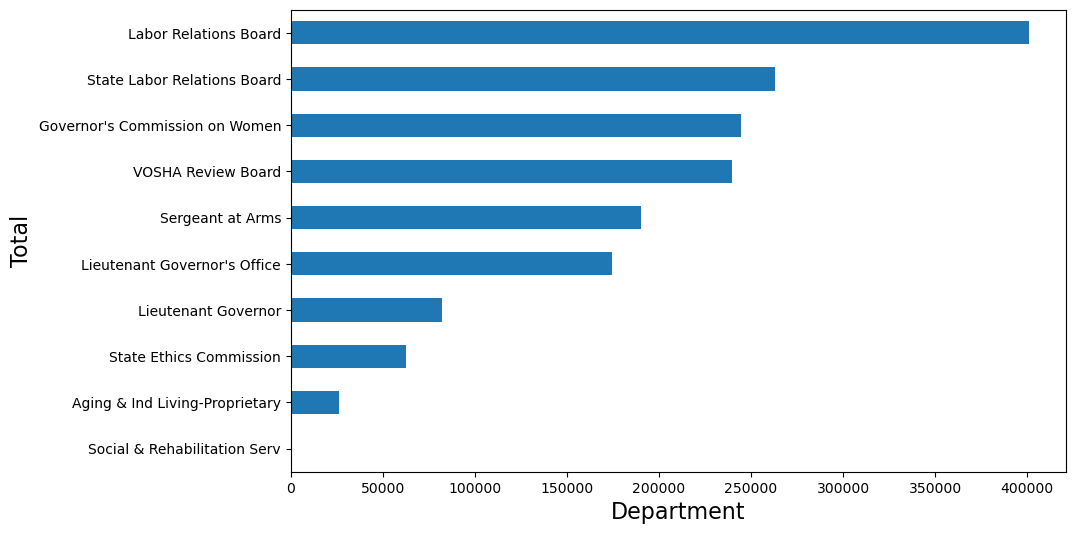

In [59]:
df.createOrReplaceTempView('VermontVendor')

sql = """SELECT Department, SUM(Amount) as Total FROM VermontVendor 
GROUP BY Department
ORDER BY Total ASC
LIMIT 10"""

plot_df = spark.sql(sql).toPandas()

fig,ax = plt.subplots(1,1,figsize=(10,6))
plot_df.plot(x = 'Department', y = 'Total', kind = 'barh', color = 'C0', ax = ax, legend = False)
ax.set_xlabel('Department', size = 16)
ax.set_ylabel('Total', size = 16)
plt.savefig('barplot.png')
plt.show()

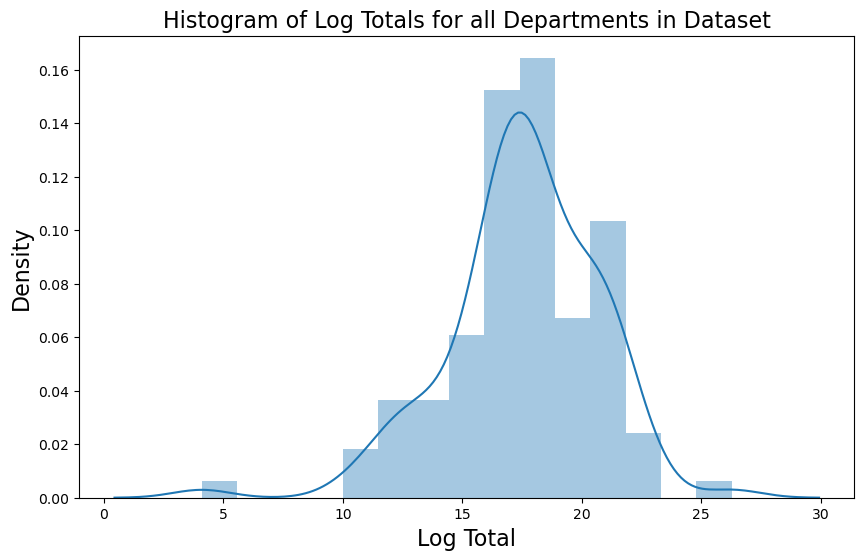

In [60]:
import numpy as np
import seaborn as sns

sql = """SELECT Department, SUM(Amount) as Total FROM VermontVendor 
GROUP BY Department"""

plot_df = spark.sql(sql).toPandas()

plt.figure(figsize = (10,6))
sns.distplot(np.log(plot_df['Total']))
plt.title('Histogram of Log Totals for all Departments in Dataset', size = 16)
plt.ylabel('Density', size = 16)
plt.xlabel('Log Total', size = 16)
plt.savefig('distplot.png')
plt.show()

In [61]:
sql = parametrize_sql_query("", "my_select", dict())
print(sql)

df = spark.sql(sql).limit(10)
df.show(truncate = False)

SELECT `Quarter Ending`, Department, Amount, State FROM VermontVendor
+--------------+---------------------------+------+-----+
|Quarter Ending|Department                 |Amount|State|
+--------------+---------------------------+------+-----+
|2009-09-30    |Environmental Conservation |930.0 |NY   |
|2009-09-30    |Environmental Conservation |930.0 |NY   |
|2009-09-30    |Vermont Veterans' Home     |24.0  |CT   |
|2009-09-30    |Vermont Veterans' Home     |420.0 |CT   |
|2009-09-30    |Corrections                |270.8 |PA   |
|2009-09-30    |Corrections                |35.0  |PA   |
|2009-09-30    |Public Safety              |971.4 |PA   |
|2009-09-30    |Agriculture, Food & Markets|60.59 |TX   |
|2009-09-30    |Agriculture, Food & Markets|541.62|TX   |
|2009-09-30    |Health                     |283.98|PA   |
+--------------+---------------------------+------+-----+



In [62]:
df.coalesce(1)\
.write.format("parquet")\
.mode("overwrite")\
.save("my_data.parquet")

In [63]:
df.coalesce(1)\
.write.mode("overwrite")\
.option("header", True)\
.option('sep',',')\
.csv("my_data.csv")